# 03 · Procurement EDA
Exploratory analysis of the cleaned dataset covering the mandated questions: price by component & country, macro co-movement, economies of scale, supplier delivery/quality/risk.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40, "display.width", 160)
from src import config as C
print("project root:", ROOT)

project root: D:\proyectos\porsche intership\Price Intelligence\automotive-procurement-price-intelligence


In [2]:
df = pd.read_csv(C.PROCESSED_QUOTES_CSV, parse_dates=['date'])
print(df.shape); df.head()

(4496, 32)
Out[2]: 
    quote_id supplier_id                supplier_name        component_type component_category country         region  year  month  order_volume  unit_price  \
0  QT-000001     SUP-001            Juno Systems Inc.  Suspension Component            Chassis     USA  North America  2022      1          1032      348.61   
1  QT-000002     SUP-002    Onyx Drivetrain Co., Ltd.        Battery Module      EV Components   China           Asia  2022      1           116    11994.56   
2  QT-000003     SUP-003  Zelos Electronics Co., Ltd.     Infotainment Unit        Electronics   China           Asia  2022      1           892     1048.94   
3  QT-000004     SUP-004         Drava Systems S.p.A.      Aluminum Casting         Powertrain   Italy         Europe  2022      1          2730      437.81   
4  QT-000005     SUP-005  Granta Components Co., Ltd.        Battery Module      EV Components   China           Asia  2022      1           118    15165.40   

   raw_material_ind

,quote_id,supplier_id,supplier_name,component_type,component_category,country,region,year,month,order_volume,unit_price,raw_material_index,energy_cost_index,exchange_rate_index,lead_time_days,on_time_delivery_rate,defect_rate,warranty_claim_rate,supplier_capacity_utilization,logistics_cost,risk_score_external,contract_type,sustainability_score,final_awarded,date,quarter,total_order_value,log_order_volume,price_ratio_vs_median,landed_unit_cost,is_eur_zone,is_overseas
0,QT-000001,SUP-001,Juno Systems Inc.,Suspension Component,Chassis,USA,North America,2022,1,1032,348.61,100.0,100.0,100.0,30,0.8290,0.0360,0.0212,0.733,6071.58,36.9,Annual Contract,51.3,0,2022-01-01,2022Q1,359765.52,6.9402,1.0227,354.49,False,True
1,QT-000002,SUP-002,"Onyx Drivetrain Co., Ltd.",Battery Module,EV Components,China,Asia,2022,1,116,11994.56,100.0,100.0,100.0,62,0.7877,0.0289,0.0151,0.863,5893.52,73.7,Spot,56.3,0,2022-01-01,2022Q1,1391368.96,4.7622,1.1404,12045.37,False,True
2,QT-000003,SUP-003,"Zelos Electronics Co., Ltd.",Infotainment Unit,Electronics,China,Asia,2022,1,892,1048.94,100.0,100.0,100.0,61,0.9422,0.0122,0.0074,0.783,6128.58,57.8,Multi-year Contract,75.0,0,2022-01-01,2022Q1,935654.48,6.7946,1.0406,1055.81,False,True
3,QT-000004,SUP-004,Drava Systems S.p.A.,Aluminum Casting,Powertrain,Italy,Europe,2022,1,2730,437.81,100.0,100.0,100.0,13,0.9809,0.0066,0.0032,0.838,1269.66,34.3,Multi-year Contract,77.9,0,2022-01-01,2022Q1,1195221.30,7.9124,1.2060,438.28,True,False
4,QT-000005,SUP-005,"Granta Components Co., Ltd.",Battery Module,EV Components,China,Asia,2022,1,118,15165.40,100.0,100.0,100.0,69,0.7425,0.0550,0.0360,0.765,5944.11,83.6,Spot,34.7,0,2022-01-01,2022Q1,1789517.20,4.7791,1.4419,15215.77,False,True


## Price by component type and by country

In [3]:
display(df.groupby('component_type').unit_price.median().sort_values(ascending=False).round(0).to_frame('median_price'))
display(df.groupby('country').unit_price.median().sort_values(ascending=False).round(0).to_frame('median_price'))

,median_price
component_type,
Battery Module,10517.0
Electric Motor Part,4140.0
Infotainment Unit,1008.0
Tire Set,644.0
Brake System,541.0
Cooling System,492.0
Aluminum Casting,363.0
Suspension Component,341.0
Interior Trim,234.0


,median_price
country,
Mexico,686.0
China,641.0
Spain,547.0
Czech Republic,540.0
USA,506.0
Italy,476.0
Germany,466.0
Poland,308.0


## Macro co-movement: monthly average price vs commodity index

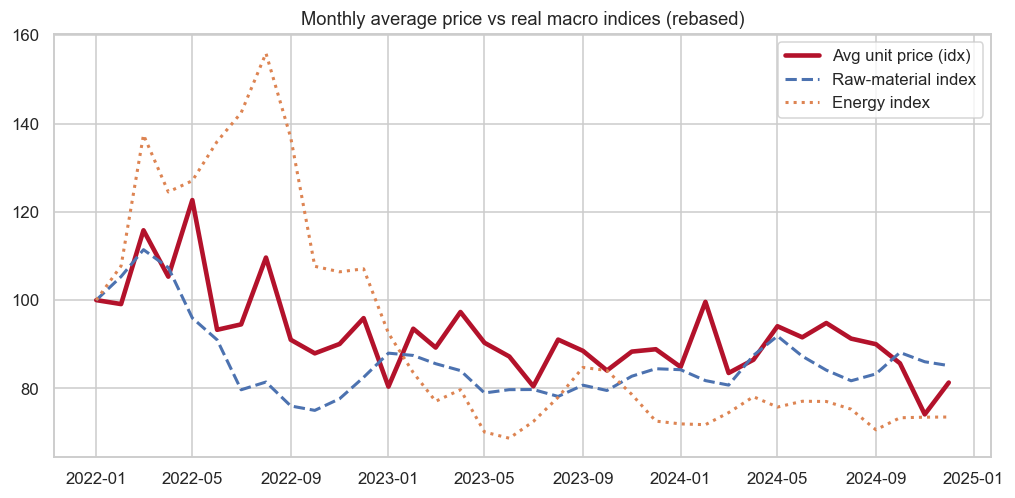

In [4]:
m = df.groupby('date').agg(avg_price=('unit_price','mean'), rawmat=('raw_material_index','mean'),
                           energy=('energy_cost_index','mean')).reset_index()
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(m.date, m.avg_price/m.avg_price.iloc[0]*100, lw=3, color='#b3122b', label='Avg unit price (idx)')
ax.plot(m.date, m.rawmat, lw=2, ls='--', label='Raw-material index')
ax.plot(m.date, m.energy, lw=2, ls=':', label='Energy index')
ax.set_title('Monthly average price vs real macro indices (rebased)'); ax.legend(); plt.show()

## Economies of scale & macro sensitivity

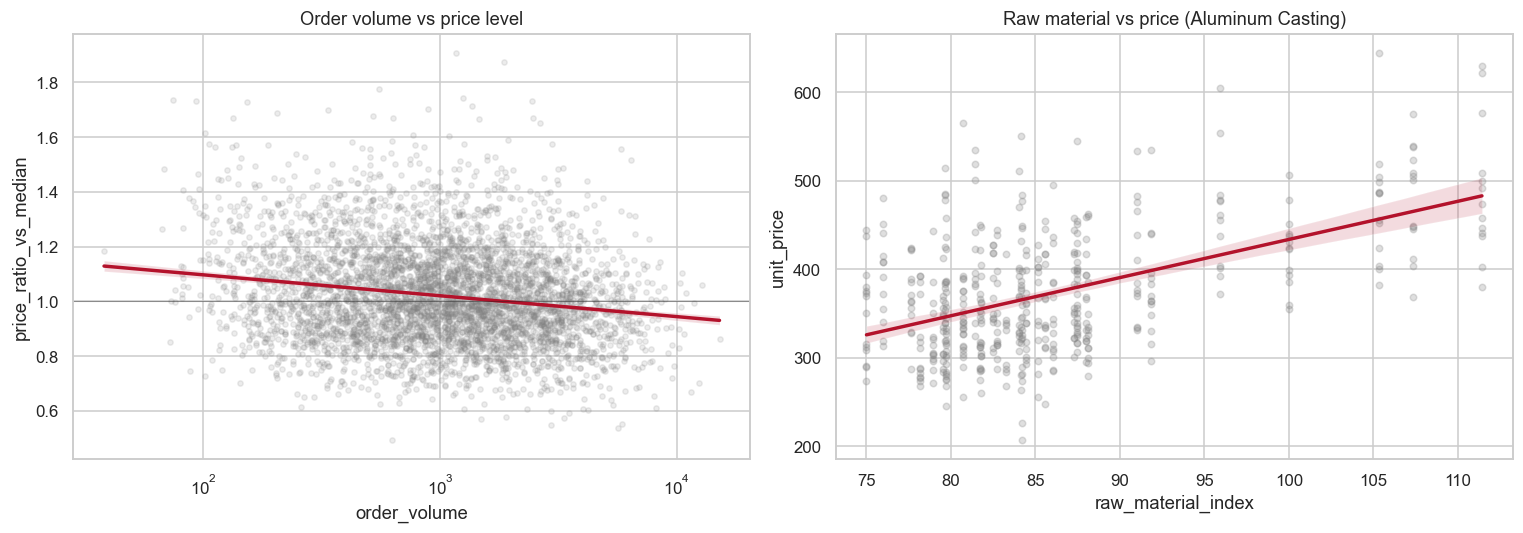

In [5]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.regplot(data=df, x='order_volume', y='price_ratio_vs_median', logx=True, ax=axes[0],
            scatter_kws=dict(alpha=.15,s=12,color='gray'), line_kws=dict(color='#b3122b'))
axes[0].set_xscale('log'); axes[0].axhline(1,color='k',lw=.7,alpha=.4); axes[0].set_title('Order volume vs price level')
ac = df[df.component_type=='Aluminum Casting']
sns.regplot(data=ac, x='raw_material_index', y='unit_price', ax=axes[1],
            scatter_kws=dict(alpha=.25,s=18,color='gray'), line_kws=dict(color='#b3122b'))
axes[1].set_title('Raw material vs price (Aluminum Casting)'); plt.tight_layout(); plt.show()

## Supplier reliability, quality and risk

Risk by region:


,risk_score_external
region,
Asia,78.8
Europe,21.2
North America,36.4


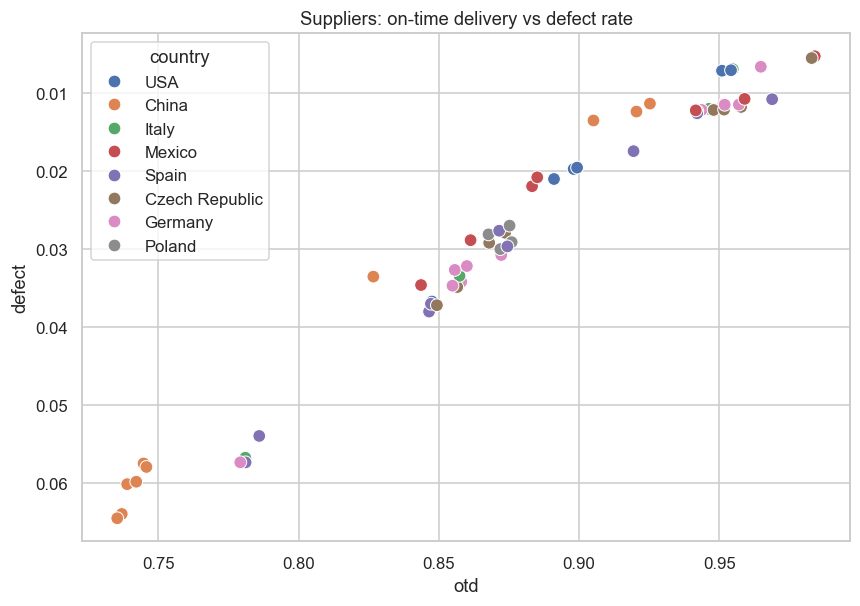

In [6]:
sup = df.groupby(['supplier_id','country']).agg(
    otd=('on_time_delivery_rate','mean'), defect=('defect_rate','mean'),
    lead=('lead_time_days','mean'), risk=('risk_score_external','mean')).reset_index()
print('Risk by region:'); display(df.groupby('region').risk_score_external.mean().round(1).to_frame())
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=sup, x='otd', y='defect', hue='country', s=70, ax=ax)
ax.set_title('Suppliers: on-time delivery vs defect rate'); ax.invert_yaxis(); plt.show()

**Read-out.** Average price tracks the real commodity & energy cycle; larger orders price below the component median; overseas regions (Asia, the Americas) carry higher risk.